In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
n = 1000

In [4]:
data = {
    "Demand": np.random.randint(50,500,n),
    "Stock_Level": np.random.randint(10,200,n),
    "Competitor_Price": np.random.uniform(10,100,n),
    "Customer_Rating": np.random.uniform(3,5,n),
    "Historical_Sales": np.random.randint(20,300,n)
}

df = pd.DataFrame(data)

In [5]:
df["Optimal_Price"] = (
    df["Competitor_Price"] * 0.6
    +df["Demand"] * 0.05
    -df["Stock_Level"] * 0.03
    +df["Customer_Rating"] * 5
)
df.head()

,Demand,Stock_Level,Competitor_Price,Customer_Rating,Historical_Sales,Optimal_Price
0,152,142,28.333112,4.676304,156,43.721389
1,485,38,18.204804,3.570581,194,51.885786
2,398,141,23.829223,3.858365,38,49.259360
3,320,147,50.832427,3.535553,214,59.767223
4,156,193,57.731895,4.578322,194,59.540746


In [6]:
df.shape

(1000, 6)

In [7]:
df.columns

Index(['Demand', 'Stock_Level', 'Competitor_Price', 'Customer_Rating',
       'Historical_Sales', 'Optimal_Price'],
      dtype='str')

In [8]:
df.info

<bound method DataFrame.info of      Demand  Stock_Level  Competitor_Price  Customer_Rating  Historical_Sales  \
0       152          142         28.333112         4.676304               156   
1       485           38         18.204804         3.570581               194   
2       398          141         23.829223         3.858365                38   
3       320          147         50.832427         3.535553               214   
4       156          193         57.731895         4.578322               194   
..      ...          ...               ...              ...               ...   
995      79           24         39.736720         3.535202               295   
996     296           36         40.636526         3.671348                92   
997     155           81         99.012552         4.498781               186   
998     100           69         66.355855         4.143824               279   
999     130          183         57.818487         4.972493               262

In [9]:
df.describe

<bound method NDFrame.describe of      Demand  Stock_Level  Competitor_Price  Customer_Rating  Historical_Sales  \
0       152          142         28.333112         4.676304               156   
1       485           38         18.204804         3.570581               194   
2       398          141         23.829223         3.858365                38   
3       320          147         50.832427         3.535553               214   
4       156          193         57.731895         4.578322               194   
..      ...          ...               ...              ...               ...   
995      79           24         39.736720         3.535202               295   
996     296           36         40.636526         3.671348                92   
997     155           81         99.012552         4.498781               186   
998     100           69         66.355855         4.143824               279   
999     130          183         57.818487         4.972493               2

In [10]:
df.isnull().sum()

Demand              0
Stock_Level         0
Competitor_Price    0
Customer_Rating     0
Historical_Sales    0
Optimal_Price       0
dtype: int64

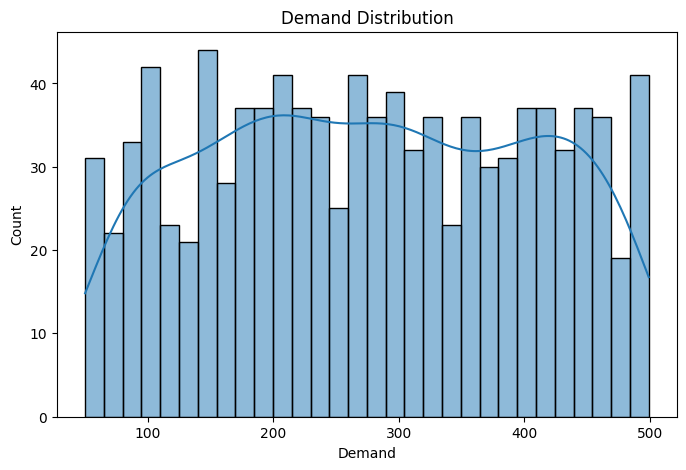

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Demand"], bins=30, kde=True)
plt.title("Demand Distribution")
plt.show()

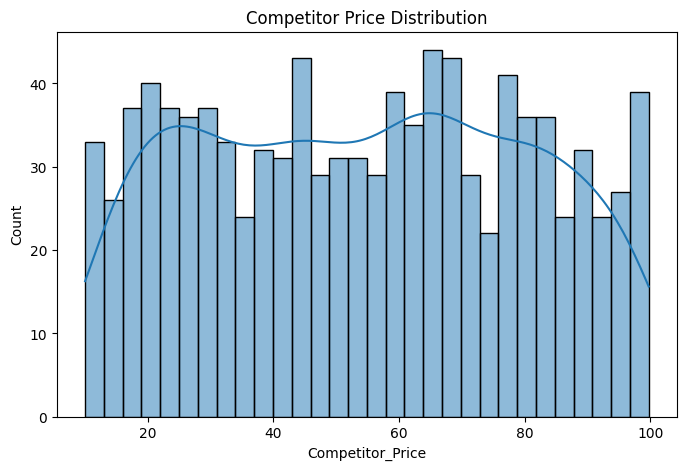

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Competitor_Price"], bins=30, kde=True)
plt.title("Competitor Price Distribution")
plt.show()

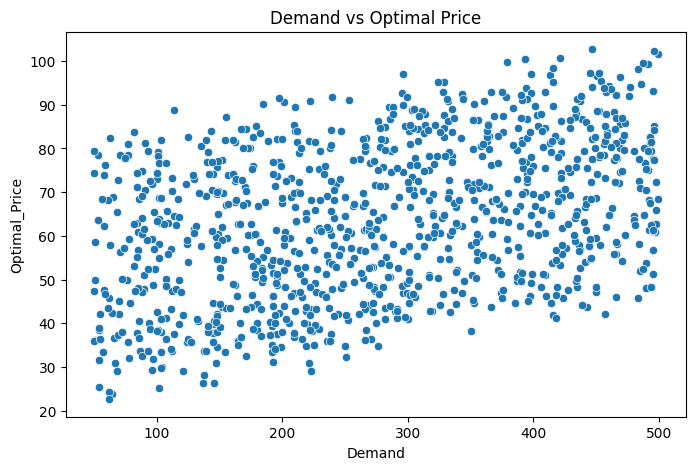

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Demand"], y=df["Optimal_Price"])
plt.title("Demand vs Optimal Price")
plt.show()

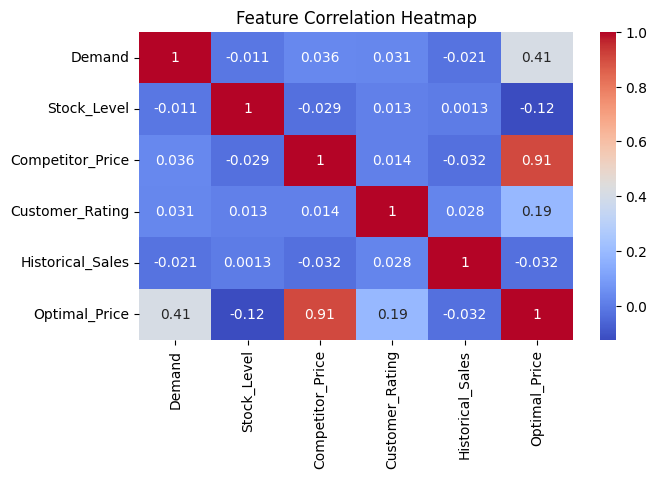

In [14]:
plt.figure(figsize=(7,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
df["Demand_Supply_Ratio"] = df["Demand"] / df["Stock_Level"]
df.head()

,Demand,Stock_Level,Competitor_Price,Customer_Rating,Historical_Sales,Optimal_Price,Demand_Supply_Ratio
0,152,142,28.333112,4.676304,156,43.721389,1.070423
1,485,38,18.204804,3.570581,194,51.885786,12.763158
2,398,141,23.829223,3.858365,38,49.259360,2.822695
3,320,147,50.832427,3.535553,214,59.767223,2.176871
4,156,193,57.731895,4.578322,194,59.540746,0.808290


In [16]:
df["Price_Difference"] = df["Competitor_Price"] - df["Optimal_Price"]
df.head()

,Demand,Stock_Level,Competitor_Price,Customer_Rating,Historical_Sales,Optimal_Price,Demand_Supply_Ratio,Price_Difference
0,152,142,28.333112,4.676304,156,43.721389,1.070423,-15.388277
1,485,38,18.204804,3.570581,194,51.885786,12.763158,-33.680982
2,398,141,23.829223,3.858365,38,49.259360,2.822695,-25.430137
3,320,147,50.832427,3.535553,214,59.767223,2.176871,-8.934796
4,156,193,57.731895,4.578322,194,59.540746,0.808290,-1.808850


In [17]:
df["Sales_Efficiency"] = df["Historical_Sales"] / df["Demand"]
df.head()

,Demand,Stock_Level,Competitor_Price,Customer_Rating,Historical_Sales,Optimal_Price,Demand_Supply_Ratio,Price_Difference,Sales_Efficiency
0,152,142,28.333112,4.676304,156,43.721389,1.070423,-15.388277,1.026316
1,485,38,18.204804,3.570581,194,51.885786,12.763158,-33.680982,0.400000
2,398,141,23.829223,3.858365,38,49.259360,2.822695,-25.430137,0.095477
3,320,147,50.832427,3.535553,214,59.767223,2.176871,-8.934796,0.668750
4,156,193,57.731895,4.578322,194,59.540746,0.808290,-1.808850,1.243590


In [18]:
noise = np.random.normal(0,5, len(df))

In [19]:
df["Optimal_Price"] = df["Optimal_Price"] + noise

In [20]:
x = df.drop("Optimal_Price", axis = 1)
y = df["Optimal_Price"]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state=42
)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()

In [25]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = model.predict(x_test)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4.089131668155733


In [29]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 26.376176325553402


In [30]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9018158456974295


In [31]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
results.head()

,Actual Price,Predicted Price
521,73.354636,70.943279
737,74.705640,76.570634
740,60.804639,61.395705
660,84.594181,74.073918
411,43.705604,44.397565


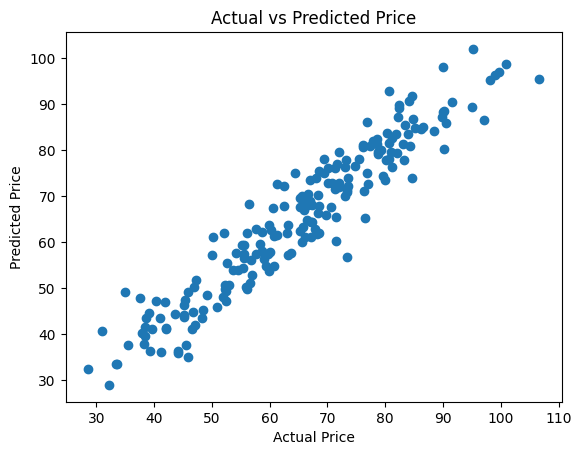

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [33]:
from sklearn.tree import DecisionTreeRegressor

In [34]:
dt_model = DecisionTreeRegressor(random_state=42)

In [35]:
dt_model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [36]:
dt_pred = dt_model.predict(x_test)

In [37]:
print("Decision Tree MAE:", mean_absolute_error(y_test, dt_pred))
print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))
print("Decision Tree R2:", r2_score(y_test, dt_pred))

Decision Tree MAE: 5.961172168881806
Decision Tree MSE: 54.86170708573898
Decision Tree R2: 0.7957797124448966


In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [40]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf_pred = rf_model.predict(x_test)

In [42]:
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest MAE: 4.294813002428999
Random Forest MSE: 28.235021826728442
Random Forest R2: 0.8948963752154554


In [43]:
feature_importance = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': feature_importance
})

In [44]:
improtance_df = importance_df.sort_values(by = 'Importance', ascending = False)
print(importance_df)

               Feature  Importance
0               Demand    0.116732
1          Stock_Level    0.008359
2     Competitor_Price    0.782226
3      Customer_Rating    0.027527
4     Historical_Sales    0.007313
5  Demand_Supply_Ratio    0.018589
6     Price_Difference    0.029006
7     Sales_Efficiency    0.010248


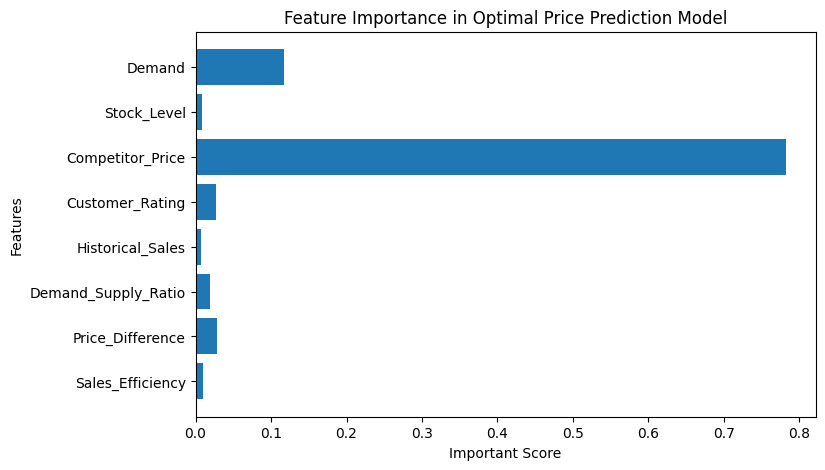

In [45]:
plt.figure(figsize = (8,5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Important Score")
plt.ylabel("Features")
plt.title("Feature Importance in Optimal Price Prediction Model")
plt.gca().invert_yaxis()
plt.show()

In [46]:
residuals = y_test - y_pred

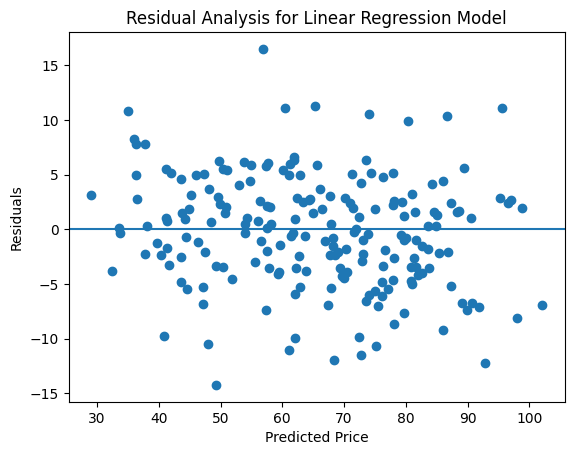

In [47]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis for Linear Regression Model")
plt.show()

### Model Comparission
##### Linear Regression R²: 0.90
##### Random Forest R²: 0.89
##### Decision Tree R²: 0.79

### Best Model Statement
##### Linear Regression performed the best with an R² score of 0.90.

## Business Insights & Conclusion

##### Based on the machine learning models and feature importance analysis, several key insights were observed.

##### 1. Demand is the most influential factor affecting optimal pricing. Products with higher demand tend to support higher prices, while lower demand          products require competitive pricing strategies.

##### 2. Competitor price also significantly impacts pricing decisions. Retailers must monitor competitor pricing to stay competitive in the market.

##### 3. Stock levels influence pricing strategy. When inventory is high, lowering prices can help clear stock faster, while limited stock can support           higher pricing.

##### 4. Customer ratings affect consumer willingness to pay. Highly rated products can often be sold at slightly higher prices compared to lower-rated          products.

#####    Overall, the model demonstrates how machine learning can support data-driven pricing decisions for retailers. By considering demand,          competition, inventory, and customer perception, businesses can optimize pricing strategies to maximize revenue and remain competitive.

## Future Improvements
##### Future improvements may include adding more real-world features such as promotional discounts, seasonal trends, and customer purchase history to further improve model accuracy.